In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
! pip install --upgrade ultralytics 
!pip install --upgrade -U ray[tune]

In [66]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import glob
import random
import yaml

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# import IPython.display as display
from PIL import Image
import cv2

from ultralytics import YOLO

%matplotlib inline

! wandb disabled

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [67]:
class CFG:
    DEBUG = False # Set to True to make quick experiments
    FRACTION = 0.05 if DEBUG else 1.0
    SEED = 42

    # classes
    CLASSES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
               'NO-Safety Vest', 'Person', 'Safety Cone',
               'Safety Vest', 'machinery', 'vehicle']
    NUM_CLASSES_TO_TRAIN = len(CLASSES)

    # training
    EPOCHS = 3 if DEBUG else 70 # 100
    BATCH_SIZE = 8
    
    BASE_MODEL = 'yolov9e' # yolov8n, yolov8s, yolov8m, yolov8l, yolov8x, yolov9c, yolov9e
    BASE_MODEL_WEIGHTS = f'{BASE_MODEL}.pt'
    EXP_NAME = f'ppe_css_{EPOCHS}_epochs'
    
    OPTIMIZER = 'auto' # SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto
    LR = 1e-3
    LR_FACTOR = 0.01
    WEIGHT_DECAY = 5e-4
    DROPOUT = 0.0
    PATIENCE = 20
    PROFILE = False
    LABEL_SMOOTHING = 0.0    

    # paths
    CUSTOM_DATASET_DIR = '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/'
    OUTPUT_DIR = '/kaggle/working/'

In [68]:
dict_file = {
    'train': os.path.join(CFG.CUSTOM_DATASET_DIR, 'train'),
    'val': os.path.join(CFG.CUSTOM_DATASET_DIR, 'valid'),
    'test': os.path.join(CFG.CUSTOM_DATASET_DIR, 'test'),
    'nc': CFG.NUM_CLASSES_TO_TRAIN,
    'names': CFG.CLASSES
    }

with open(os.path.join(CFG.OUTPUT_DIR, 'data.yaml'), 'w+') as file:
    yaml.dump(dict_file, file)

In [69]:
### read yaml file created
def read_yaml_file(file_path = CFG.CUSTOM_DATASET_DIR):
    with open(file_path, 'r') as file:
        try:
            data = yaml.safe_load(file)
            return data
        except yaml.YAMLError as e:
            print("Error reading YAML:", e)
            return None

### print it with newlines
def print_yaml_data(data):
    formatted_yaml = yaml.dump(data, default_style=False)
    print(formatted_yaml)

file_path = os.path.join(CFG.OUTPUT_DIR, 'data.yaml')
yaml_data = read_yaml_file(file_path)

if yaml_data:
    print_yaml_data(yaml_data)

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test
train: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train
val: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid



In [70]:
def display_image(image, print_info = True, hide_axis = False):
    if isinstance(image, str):  # Check if it's a file path
        img = Image.open(image)
        plt.imshow(img)
    elif isinstance(image, np.ndarray):  # Check if it's a NumPy array
        image = image[..., ::-1]  # BGR to RGB
        img = Image.fromarray(image)
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format")

    if print_info:
        print('Type: ', type(img), '\n')
        print('Shape: ', np.array(img).shape, '\n')

    if hide_axis:
        plt.axis('off')

    plt.show()

Type:  <class 'PIL.JpegImagePlugin.JpegImageFile'> 

Shape:  (640, 640, 3) 



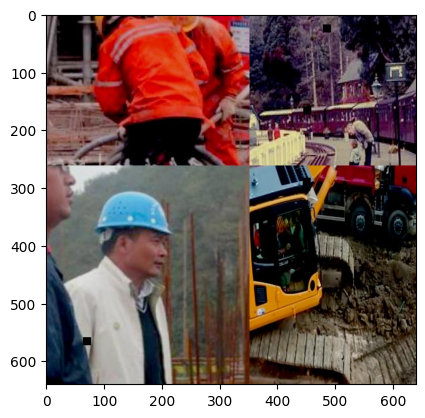

In [71]:
example_image_path = CFG.CUSTOM_DATASET_DIR + 'train/images/-2297-_png_jpg.rf.9fff3740d864fbec9cda50d783ad805e.jpg'
display_image(example_image_path, print_info = True, hide_axis = False)

In [72]:
def plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED):
    
    random.seed(seed)

    # Get a list of image files in the folder
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg', '.gif'))]

    # Ensure that we have at least num_images files to choose from
    if len(image_files) < num_images:
        raise ValueError("Not enough images in the folder")

    # Randomly select num_images image files
    selected_files = random.sample(image_files, num_images)

    # Create a subplot grid
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i, file_name in enumerate(selected_files):
        # Open and display the image using PIL
        img = Image.open(os.path.join(folder_path, file_name))
        
        if num_rows == 1:
            ax = axes[i % num_cols]
        else:
            ax = axes[i // num_cols, i % num_cols]
        
        ax.imshow(img)
        ax.axis('off')
        # ax.set_title(file_name)

    # Remove empty subplots
    for i in range(num_images, num_rows * num_cols):
        if num_rows == 1:
            fig.delaxes(axes[i % num_cols])
        else:
            fig.delaxes(axes[i // num_cols, i % num_cols])

    plt.tight_layout()
    plt.show()

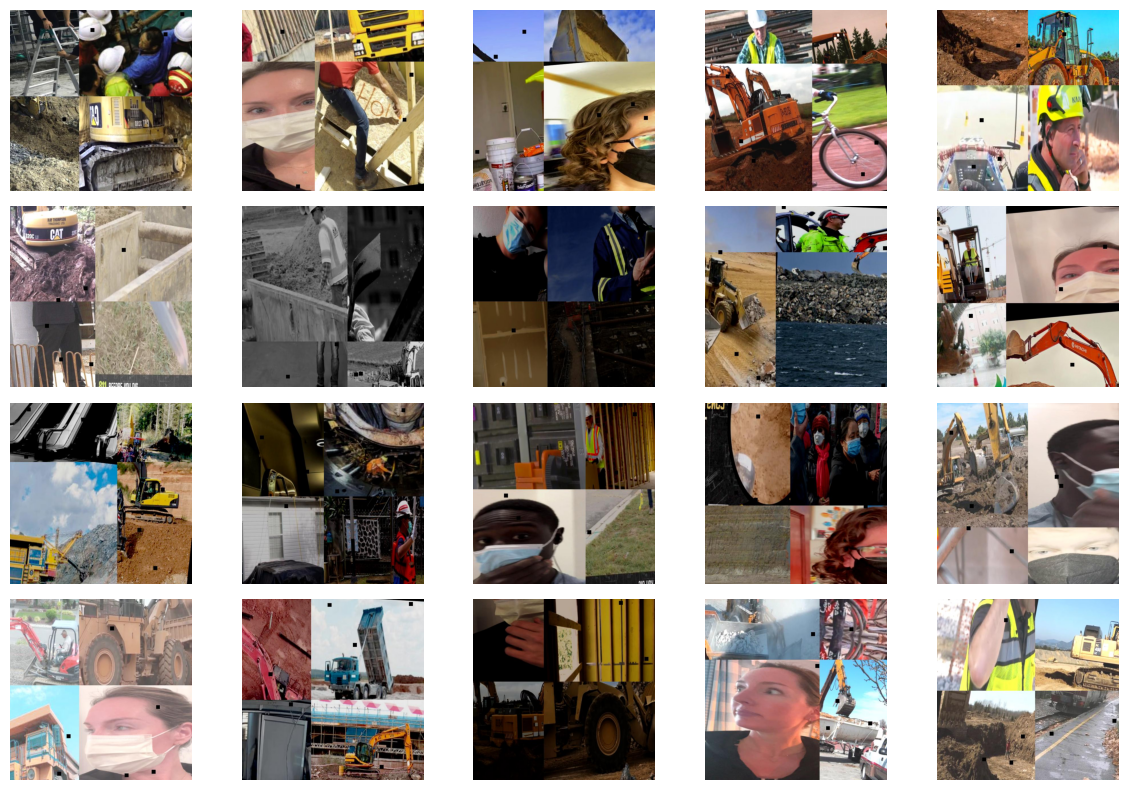

In [73]:
folder_path = CFG.CUSTOM_DATASET_DIR + 'train/images/'
plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED)

In [74]:
def get_image_properties(image_path):
    # Read the image file
    img = cv2.imread(image_path)

    # Check if the image file is read successfully
    if img is None:
        raise ValueError("Could not read image file")

    # Get image properties
    properties = {
        "width": img.shape[1],
        "height": img.shape[0],
        "channels": img.shape[2] if len(img.shape) == 3 else 1,
        "dtype": img.dtype,
    }

    return properties

In [75]:
img_properties = get_image_properties(example_image_path)
img_properties

{'width': 640, 'height': 640, 'channels': 3, 'dtype': dtype('uint8')}

In [76]:
class_idx = {str(i): CFG.CLASSES[i] for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

class_stat = {}
data_len = {}
class_info = []

for mode in ['train', 'valid', 'test']:
    class_count = {CFG.CLASSES[i]: 0 for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

    path = os.path.join(CFG.CUSTOM_DATASET_DIR, mode, 'labels')

    for file in os.listdir(path):
        with open(os.path.join(path, file)) as f:
            lines = f.readlines()

            for cls in set([line[0] for line in lines]):
                class_count[class_idx[cls]] += 1

    data_len[mode] = len(os.listdir(path))
    class_stat[mode] = class_count

    class_info.append({'Mode': mode, **class_count, 'Data_Volume': data_len[mode]})

dataset_stats_df = pd.DataFrame(class_info)
with pd.option_context('display.max_columns', None): 
    display(dataset_stats_df)

,Mode,Hardhat,Mask,NO-Hardhat,NO-Mask,NO-Safety Vest,Person,Safety Cone,Safety Vest,machinery,vehicle,Data_Volume
0,train,1314,1096,1380,1531,1864,2526,631,1319,2101,744,2605
1,valid,42,19,37,44,56,84,13,28,26,16,114
2,test,30,16,25,30,36,59,8,22,22,15,82


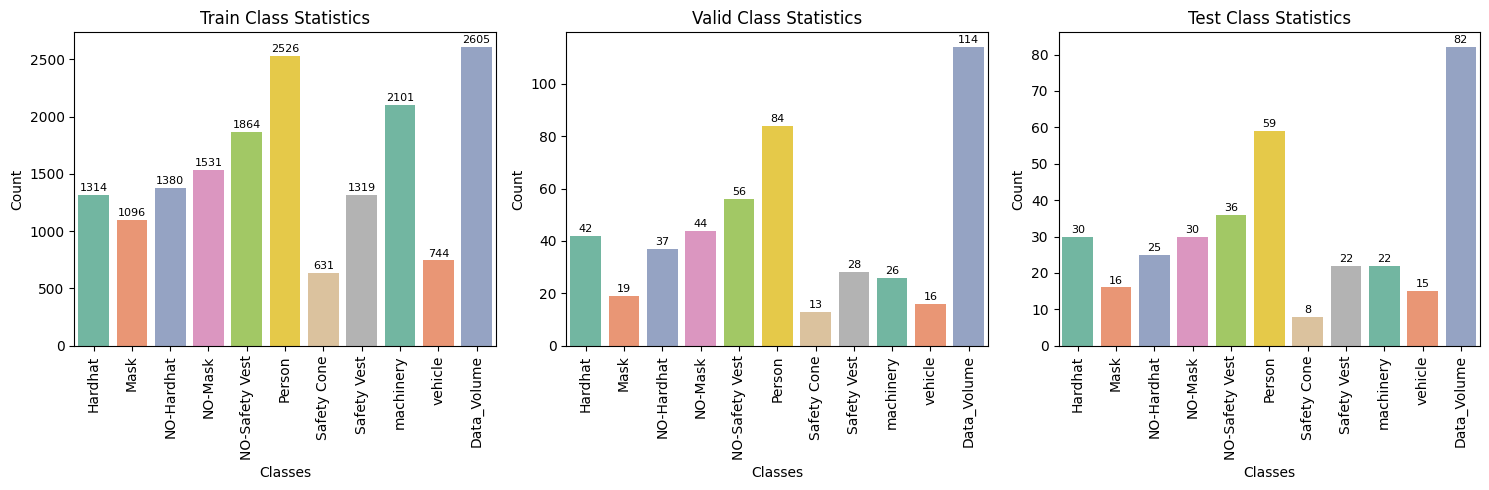

In [77]:
# Create subplots with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot vertical bar plots for each mode in subplots
for i, mode in enumerate(['train', 'valid', 'test']):
    sns.barplot(
        data=dataset_stats_df[dataset_stats_df['Mode'] == mode].drop(columns='Mode'),
        orient='v',
        ax=axes[i],
        palette='Set2'
    )
    
    axes[i].set_title(f'{mode.capitalize()} Class Statistics')
    axes[i].set_xlabel('Classes')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=90) 

    # Add annotations on top of each bar
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

In [78]:
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

results = model.predict(
    source = example_image_path,

    classes = [0],
    conf = 0.30,
#     device = [0,1], # inference with dual GPU
    device = None, # inference with CPU
    imgsz = (img_properties['height'], img_properties['width']),

    save = True,
    save_txt = True,
    save_conf = True,
    exist_ok = True,
)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train/images/-2297-_png_jpg.rf.9fff3740d864fbec9cda50d783ad805e.jpg: 640x640 8 persons, 48.9ms
Speed: 1.6ms preprocess, 48.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


Type:  <class 'PIL.JpegImagePlugin.JpegImageFile'> 

Shape:  (640, 640, 3) 



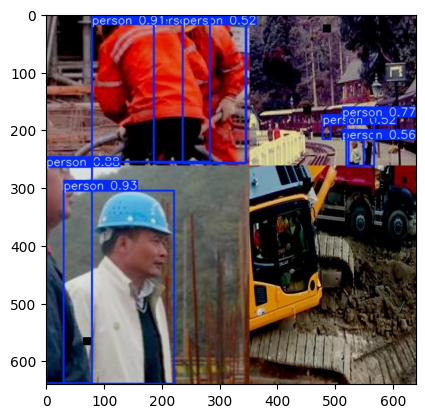

In [79]:
### check predictions with base model
example_image_inference_output = example_image_path.split('/')[-1]
display_image(f'runs/detect/predict/{example_image_inference_output}')

In [80]:
### Test base model on video (LIMITED FRAMES)
video_path = '/kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4'
MAX_FRAMES = 100  # Process only first 100 frames to avoid infinite loop

if os.path.exists(video_path):
    print(f'Testing base model on video: {video_path}')
    print(f'Processing first {MAX_FRAMES} frames only...\n')
    
    # Open video to get info
    cap = cv2.VideoCapture(video_path)
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    
    print(f'Video info: {total_video_frames} total frames, {fps:.2f} FPS')
    print(f'Full video duration: {total_video_frames/fps:.2f} seconds')
    print(f'Processing duration: {MAX_FRAMES/fps:.2f} seconds\n')
    
    # Process limited frames
    frame_count = 0
    total_detections = 0
    sample_frames = []
    
    # Run inference
    base_video_results = model.predict(
        source=video_path,
        conf=0.30,
        imgsz=640,
        device=None,  # CPU
        save=False,  # Don't save to speed up
        stream=True
    )
    
    for r in base_video_results:
        frame_count += 1
        total_detections += len(r.boxes)
        
        # Save every 20th frame for display
        if frame_count % 20 == 0:
            sample_frames.append(r.plot())  # Get annotated frame
            print(f'Processed {frame_count} frames, {len(r.boxes)} detections in this frame')
        
        # STOP after MAX_FRAMES to prevent infinite loop
        if frame_count >= MAX_FRAMES:
            print(f'\n⚠️ Stopped at {MAX_FRAMES} frames (limit reached)')
            break
    
    print(f'\n{"="*60}')
    print(f'Base Model Video Test Complete!')
    print(f'{"="*60}')
    print(f'Frames processed: {frame_count}/{total_video_frames}')
    print(f'Total detections: {total_detections}')
    print(f'Average detections per frame: {total_detections/frame_count:.2f}')
    
    # Display sample frames
    if sample_frames:
        print(f'\nDisplaying {len(sample_frames)} sample frames:')
        fig, axes = plt.subplots(1, min(5, len(sample_frames)), figsize=(15, 3))
        if len(sample_frames) == 1:
            axes = [axes]
        
        for i, frame in enumerate(sample_frames[:5]):
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame_rgb)
            axes[i].axis('off')
            axes[i].set_title(f'Frame {(i+1)*20}')
        
        plt.tight_layout()
        plt.show()
else:
    print(f'Video not found at: {video_path}')

Testing base model on video: /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4
Processing first 100 frames only...

Video info: 648 total frames, 29.97 FPS
Full video duration: 21.62 seconds
Processing duration: 3.34 seconds


video 1/1 (frame 1/648) /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4: 384x640 3 persons, 85.4ms
video 1/1 (frame 2/648) /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4: 384x640 3 persons, 37.9ms
video 1/1 (frame 3/648) /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4: 384x640 3 persons, 37.8ms
video 1/1 (frame 4/648) /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4: 384x640 3 persons, 35.3ms
video 1/1 (frame 5/648) /kaggle/input/construction-site-safety-image-dataset-roboflow/sou

KeyboardInterrupt: 

In [ ]:
### Test base model on video - Create output video with detections
video_path = '/kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4'
MAX_FRAMES = 150  # Process first 150 frames (5 seconds of video)

if os.path.exists(video_path):
    print(f'Testing base model on video: {video_path}')
    print(f'Creating output video with detections...\n')
    
    # Open input video
    cap = cv2.VideoCapture(video_path)
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f'Video info: {total_video_frames} frames, {fps:.2f} FPS, {width}x{height}')
    print(f'Processing {MAX_FRAMES} frames ({MAX_FRAMES/fps:.1f} seconds)\n')
    
    # Create output video writer
    output_video_path = f'{CFG.OUTPUT_DIR}base_model_detection_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    
    # Process frames
    frame_count = 0
    total_detections = 0
    sample_frames = []
    
    print('Processing video...')
    while cap.isOpened() and frame_count < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Run detection on frame
        results = model.predict(frame, conf=0.30, verbose=False)
        
        # Get annotated frame
        annotated_frame = results[0].plot()
        
        # Write to output video
        out.write(annotated_frame)
        
        # Track stats
        frame_count += 1
        detections = len(results[0].boxes)
        total_detections += detections
        
        # Save sample frames for preview
        if frame_count % 30 == 0:
            sample_frames.append(annotated_frame)
            print(f'✓ Frame {frame_count}/{MAX_FRAMES} - {detections} objects detected')
    
    # Cleanup
    cap.release()
    out.release()
    
    print(f'\n{"="*60}')
    print(f'Video Processing Complete!')
    print(f'{"="*60}')
    print(f'Frames processed: {frame_count}')
    print(f'Total detections: {total_detections}')
    print(f'Average detections per frame: {total_detections/frame_count:.2f}')
    print(f'\n✅ Output video saved: {output_video_path}')
    print(f'📹 Video duration: {frame_count/fps:.1f} seconds')
    print(f'💾 Download from Kaggle output!')
    
    # Display sample frames from the output video
    if sample_frames:
        print(f'\n📸 Preview - Sample frames from output video:')
        num_samples = min(5, len(sample_frames))
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
        if num_samples == 1:
            axes = [axes]
        
        for i, frame in enumerate(sample_frames[:num_samples]):
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame_rgb)
            axes[i].axis('off')
            axes[i].set_title(f'Frame {(i+1)*30}', fontsize=10)
        
        plt.tight_layout()
        plt.show()
else:
    print(f'Video not found at: {video_path}')

In [81]:
print('Model: ', CFG.BASE_MODEL_WEIGHTS)
print('Epochs: ', CFG.EPOCHS)
print('Batch: ', CFG.BATCH_SIZE)

Model:  yolov9e.pt
Epochs:  70
Batch:  8


In [82]:
### Load pre-trained YOLO model
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

In [83]:
%%time

### train
model.train(
    data = os.path.join(CFG.OUTPUT_DIR, 'data.yaml'),

    task = 'detect',

    imgsz = (img_properties['height'], img_properties['width']),

    epochs = CFG.EPOCHS,
    batch = CFG.BATCH_SIZE,
    optimizer = CFG.OPTIMIZER,
    lr0 = CFG.LR,
    lrf = CFG.LR_FACTOR,
    weight_decay = CFG.WEIGHT_DECAY,
    dropout = CFG.DROPOUT,
    fraction = CFG.FRACTION,
    patience = CFG.PATIENCE,
    profile = CFG.PROFILE,
    label_smoothing = CFG.LABEL_SMOOTHING,

    name = f'{CFG.BASE_MODEL}_{CFG.EXP_NAME}',
    seed = CFG.SEED,
    
    val = True,
    amp = True,    
    exist_ok = True,
    resume = False,
    device = [0], 
#     device = None, # CPU run
    verbose = False,
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(640, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9e.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9e_ppe_css_70_epochs, nbs=64, nms=Fa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d5e3495f590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [85]:
### AUTO-SAVE MODEL AFTER TRAINING COMPLETES
print('\n' + '='*70)
print('🎉 TRAINING COMPLETED! Auto-saving model for download...')
print('='*70 + '\n')

import shutil
from datetime import datetime

# Define paths
best_model_path = f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/weights/best.pt'

# Create timestamped copy for easy download
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
final_model_name = f'ppe_detection_model_{timestamp}.pt'
final_model_path = os.path.join(CFG.OUTPUT_DIR, final_model_name)

# Copy the best model
if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, final_model_path)
    
    file_size_mb = os.path.getsize(final_model_path) / (1024*1024)
    
    print(f'✅ MODEL SAVED SUCCESSFULLY!')
    print(f'\n📁 File Location: {final_model_path}')
    print(f'📦 File Name: {final_model_name}')
    print(f'💾 File Size: {file_size_mb:.2f} MB')
    print(f'\n{"="*70}')
    print(f'⬇️  DOWNLOAD THIS FILE from Kaggle Output:')
    print(f'   → {final_model_name}')
    print(f'{"="*70}')
    print(f'\n📝 Model trained with:')
    print(f'   • Base Model: {CFG.BASE_MODEL}')
    print(f'   • Epochs: {CFG.EPOCHS}')
    print(f'   • Batch Size: {CFG.BATCH_SIZE}')
    print(f'   • Classes: {CFG.NUM_CLASSES_TO_TRAIN}')
    print(f'\n💤 Your model is ready! Sleep well and test tomorrow!')
    print('='*70)
else:
    print(f'⚠️  Warning: Model not found at {best_model_path}')
    print('Check the training logs above for any errors.')


🎉 TRAINING COMPLETED! Auto-saving model for download...

✅ MODEL SAVED SUCCESSFULLY!

📁 File Location: /kaggle/working/ppe_detection_model_20260116_0254.pt
📦 File Name: ppe_detection_model_20260116_0254.pt
💾 File Size: 111.84 MB

⬇️  DOWNLOAD THIS FILE from Kaggle Output:
   → ppe_detection_model_20260116_0254.pt

📝 Model trained with:
   • Base Model: yolov9e
   • Epochs: 70
   • Batch Size: 8
   • Classes: 10

💤 Your model is ready! Sleep well and test tomorrow!


In [86]:
# Export the model
model.export(
    format = 'onnx', # openvino, onnx, engine, tflite
    imgsz = (img_properties['height'], img_properties['width']),
    half = False,
    int8 = False,
    simplify = False,
    nms = False,
)


Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv9e summary (fused): 279 layers, 57,384,110 parameters, 0 gradients, 189.2 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (111.8 MB)

ONNX: starting export with onnx 1.20.0 opset 22...
ONNX: export success ✅ 6.2s, saved as '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.onnx' (219.3 MB)

Export complete (11.4s)
Results saved to /kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs

'/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.onnx'

In [87]:
results_paths = [
    i for i in
    glob.glob(f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.png') +
    glob.glob(f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.jpg')
    if 'batch' not in i
]

results_paths

['/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxP_curve.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxR_curve.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxPR_curve.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/confusion_matrix.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxF1_curve.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/confusion_matrix_normalized.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/results.png',
 '/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/labels.jpg']

/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxF1_curve.png


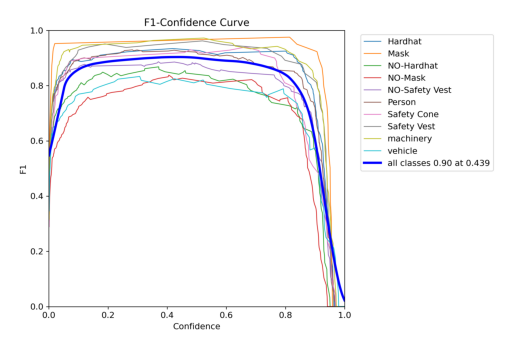



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxPR_curve.png


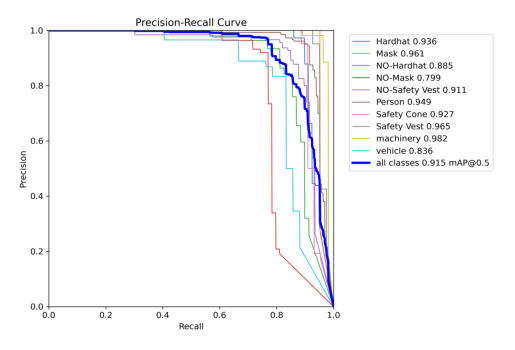



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxP_curve.png


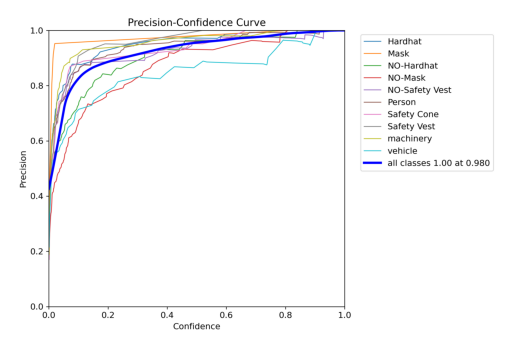



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/BoxR_curve.png


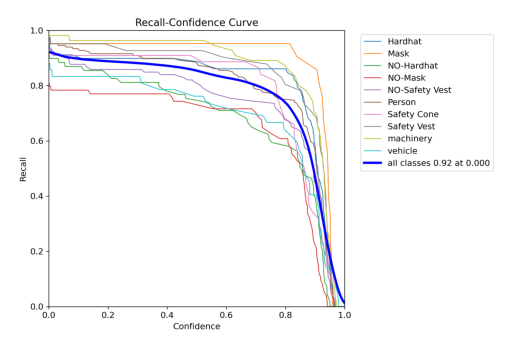



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/confusion_matrix.png


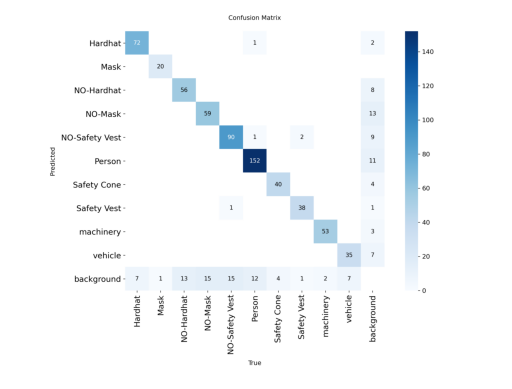



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/confusion_matrix_normalized.png


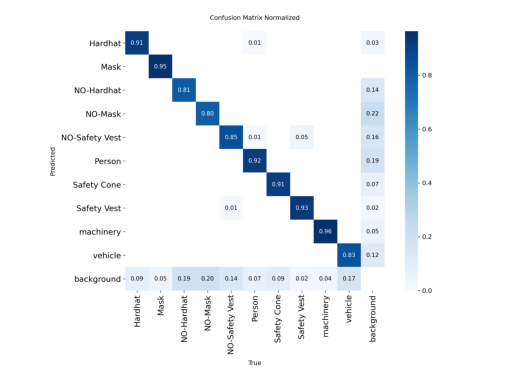



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/labels.jpg


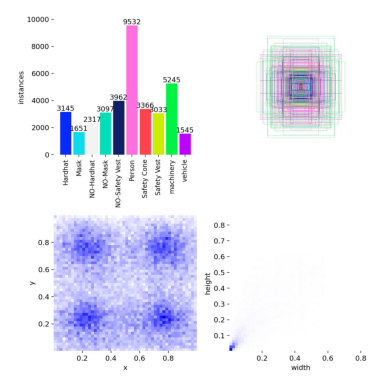



/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/results.png


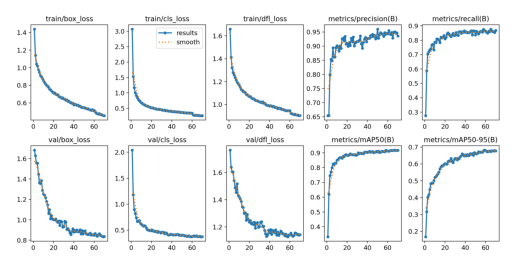

In [88]:
for file in sorted(results_paths):
    print(file)
    display_image(file, print_info = False, hide_axis = True)
    print('\n')

In [89]:
df = pd.read_csv(f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/results.csv')
df = df.rename(columns=lambda x: x.replace(" ", ""))
df.to_csv(f'{CFG.OUTPUT_DIR}training_log_df.csv', index=False)
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,434.626,1.43976,3.07203,1.65891,0.65388,0.27527,0.33231,0.16837,1.68350,2.04152,1.76531,0.000712,0.000237,0.000712,0.000237,0.000712,0.000237,0.000712,0.000237
1,2,816.982,1.14224,1.53532,1.41279,0.65453,0.58696,0.61968,0.31703,1.62939,1.17865,1.64054,0.001406,0.000469,0.001406,0.000469,0.001406,0.000469,0.001406,0.000469
2,3,1183.600,1.04222,1.16921,1.32229,0.79866,0.70413,0.74639,0.40301,1.55582,0.89321,1.60768,0.002079,0.000693,0.002079,0.000693,0.002079,0.000693,0.002079,0.000693
3,4,1545.440,1.01891,1.00418,1.28056,0.85319,0.71957,0.76971,0.41693,1.55515,0.82386,1.60420,0.002051,0.000684,0.002051,0.000684,0.002051,0.000684,0.002051,0.000684
4,5,1907.960,0.97715,0.91580,1.26065,0.84883,0.73313,0.80061,0.44869,1.44752,0.73764,1.54197,0.002021,0.000674,0.002021,0.000674,0.002021,0.000674,0.002021,0.000674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,66,23997.200,0.46976,0.26927,0.91037,0.94893,0.86608,0.91705,0.67848,0.84929,0.37666,1.15376,0.000173,0.000058,0.000173,0.000058,0.000173,0.000058,0.000173,0.000058
66,67,24359.200,0.46740,0.26761,0.90942,0.95083,0.86206,0.91847,0.67681,0.84386,0.37845,1.14465,0.000143,0.000048,0.000143,0.000048,0.000143,0.000048,0.000143,0.000048
67,68,24720.700,0.46383,0.26533,0.90953,0.94525,0.86018,0.91526,0.67730,0.83672,0.37764,1.14482,0.000112,0.000037,0.000112,0.000037,0.000112,0.000037,0.000112,0.000037
68,69,25082.600,0.45781,0.26225,0.90297,0.94668,0.85430,0.91684,0.67964,0.83388,0.37244,1.14009,0.000082,0.000027,0.000082,0.000027,0.000082,0.000027,0.000082,0.000027


In [90]:
print('*'*50)
print('\nBest Training Box loss: ', df['train/box_loss'].min(), ', on epoch: ', df['train/box_loss'].argmin() + 1, '\n')
print('\nBest Validation Box loss: ', df['val/box_loss'].min(), ', on epoch: ', df['val/box_loss'].argmin() + 1, '\n')

print('='*50)
print('\nBest Training Cls loss: ', df['train/cls_loss'].min(), ', on epoch: ', df['train/cls_loss'].argmin() + 1, '\n')
print('\nBest Validation Cls loss: ', df['val/cls_loss'].min(), ', on epoch: ', df['val/cls_loss'].argmin() + 1, '\n')

print('='*50)
print('\nBest Training DFL loss: ', df['train/dfl_loss'].min(), ', on epoch: ', df['train/dfl_loss'].argmin() + 1, '\n')
print('\nBest Validation DFL loss: ', df['val/dfl_loss'].min(), ', on epoch: ', df['val/dfl_loss'].argmin() + 1, '\n')

**************************************************

Best Training Box loss:  0.4552 , on epoch:  70 


Best Validation Box loss:  0.83388 , on epoch:  69 


Best Training Cls loss:  0.26123 , on epoch:  70 


Best Validation Cls loss:  0.37244 , on epoch:  69 


Best Training DFL loss:  0.90297 , on epoch:  69 


Best Validation DFL loss:  1.12764 , on epoch:  58 



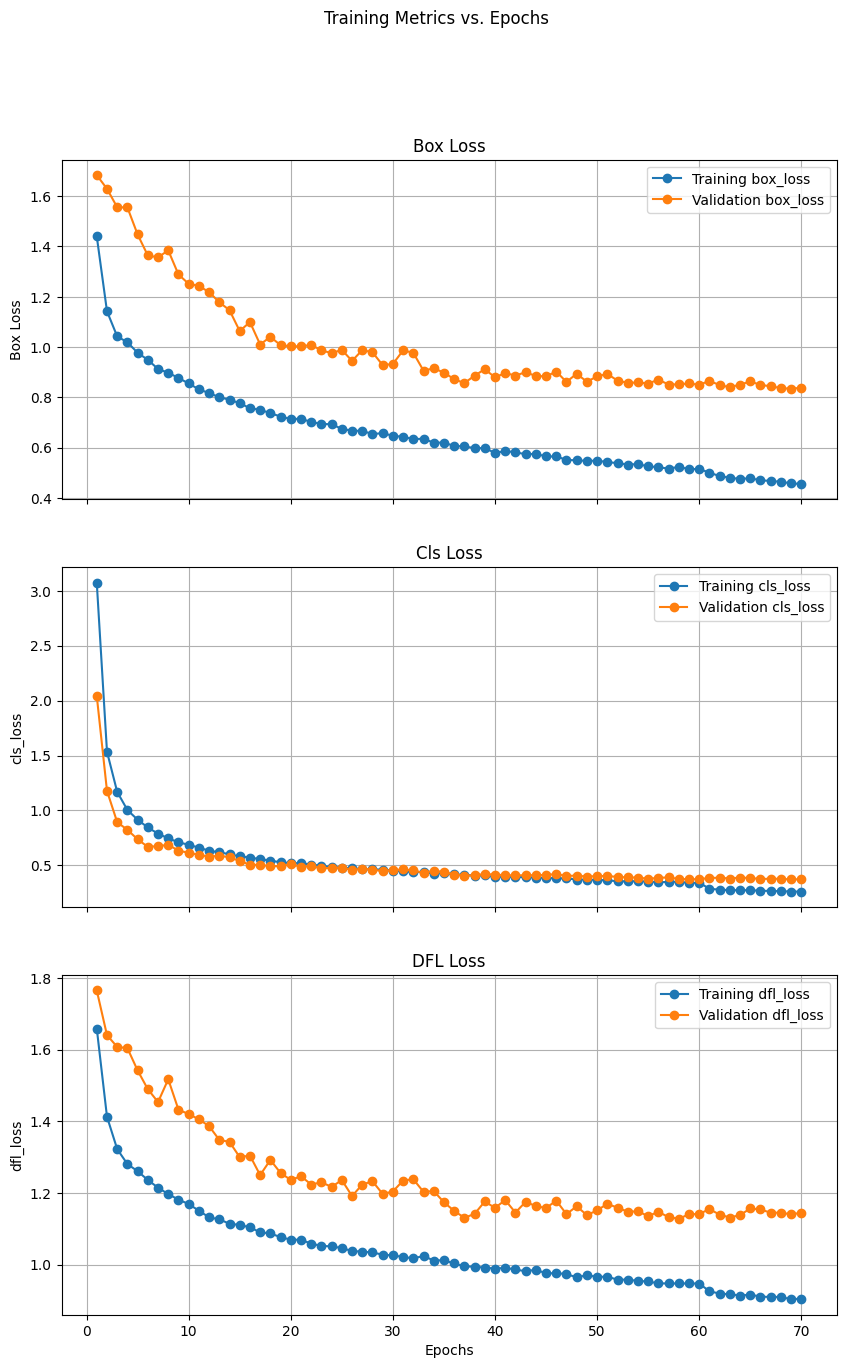

In [91]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

### Training and Validation box_loss
ax1.set_title('Box Loss')
ax1.plot(df['epoch'], df['train/box_loss'], label='Training box_loss', marker='o', linestyle='-')
ax1.plot(df['epoch'], df['val/box_loss'], label='Validation box_loss', marker='o', linestyle='-')
ax1.set_ylabel('Box Loss')
ax1.legend()
ax1.grid(True)

### Training and Validation cls_loss
ax2.set_title('Cls Loss')
ax2.plot(df['epoch'], df['train/cls_loss'], label='Training cls_loss', marker='o', linestyle='-')
ax2.plot(df['epoch'], df['val/cls_loss'], label='Validation cls_loss', marker='o', linestyle='-')
ax2.set_ylabel('cls_loss')
ax2.legend()
ax2.grid(True)

### Training and Validation dfl_loss
ax3.set_title('DFL Loss')
ax3.plot(df['epoch'], df['train/dfl_loss'], label='Training dfl_loss', marker='o', linestyle='-')
ax3.plot(df['epoch'], df['val/dfl_loss'], label='Validation dfl_loss', marker='o', linestyle='-')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('dfl_loss')
ax3.legend()
ax3.grid(True)

plt.suptitle('Training Metrics vs. Epochs')
plt.show()

In [92]:
validation_results_paths = [
    i for i in
    glob.glob(f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.png') +
    glob.glob(f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.jpg')
    if 'val_batch' in i
]

len(validation_results_paths)

6

In [93]:
if len(validation_results_paths) >= 1:
    print(validation_results_paths[-1])

/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/val_batch2_pred.jpg


/kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/val_batch2_pred.jpg


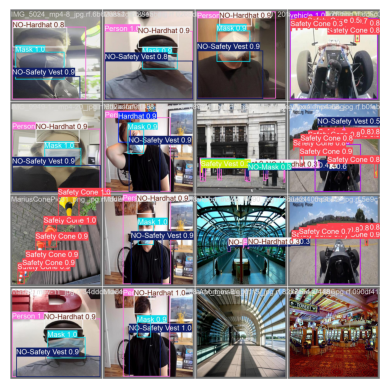

In [94]:
### check predictions or labels from a random validation batch
if len(validation_results_paths) >= 1:
    val_img_path = random.choice(validation_results_paths)
    print(val_img_path)
    display_image(val_img_path, print_info = False, hide_axis = True)

In [95]:
### Load the best trained model
best_model_path = f'{CFG.OUTPUT_DIR}runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/weights/best.pt'
trained_model = YOLO(best_model_path)

print(f'Loaded best model from: {best_model_path}')

Loaded best model from: /kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.pt


Test

In [96]:
### Get random test images
test_images_path = CFG.CUSTOM_DATASET_DIR + 'test/images/'
test_image_files = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f'Total test images: {len(test_image_files)}')

Total test images: 82



image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/thumbnail-ba5c72edb320b49a69e86b05775c49b2-scaled-1_jpeg_jpg.rf.3bb460e284098219861b894fb0db13d5.jpg: 640x640 7 Masks, 9 NO-Hardhats, 9 NO-Safety Vests, 9 Persons, 48.6ms
Speed: 1.8ms preprocess, 48.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/images

Test Image 1: thumbnail-ba5c72edb320b49a69e86b05775c49b2-scaled-1_jpeg_jpg.rf.3bb460e284098219861b894fb0db13d5.jpg
Detected 34 objects:
  - NO-Safety Vest: 0.95
  - NO-Safety Vest: 0.94
  - Mask: 0.93
  - NO-Hardhat: 0.92
  - Mask: 0.92
  - Mask: 0.92
  - Person: 0.92
  - NO-Hardhat: 0.92
  - NO-Hardhat: 0.92
  - NO-Hardhat: 0.92
  - NO-Safety Vest: 0.92
  - Person: 0.91
  - Person: 0.91
  - NO-Safety Vest: 0.91
  - Mask: 0.91
  - Mask: 0.91
  - NO-Hardhat: 0.90
  - NO-Safety Vest: 0.90
  - Mask: 0.90
  - NO-Hardhat: 0.90
  - Person: 0.90
  - NO-Safety Vest: 0.90
  - Person: 0.

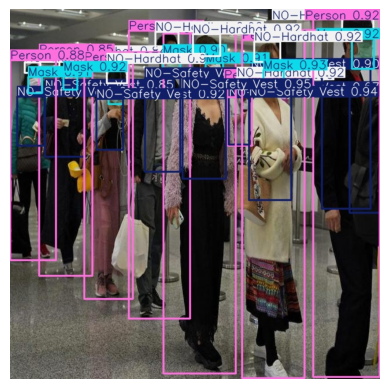


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/ka_01181_png_jpg.rf.154ee4ef254eabd62e316be50470c578.jpg: 640x640 2 NO-Safety Vests, 3 Persons, 14 Safety Cones, 1 vehicle, 44.8ms
Speed: 1.6ms preprocess, 44.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/images

Test Image 2: ka_01181_png_jpg.rf.154ee4ef254eabd62e316be50470c578.jpg
Detected 20 objects:
  - vehicle: 0.95
  - Safety Cone: 0.87
  - Safety Cone: 0.82
  - Person: 0.82
  - Safety Cone: 0.80
  - Safety Cone: 0.71
  - Safety Cone: 0.67
  - Safety Cone: 0.63
  - Person: 0.62
  - Safety Cone: 0.58
  - Person: 0.57
  - Safety Cone: 0.56
  - Safety Cone: 0.54
  - Safety Cone: 0.53
  - NO-Safety Vest: 0.52
  - NO-Safety Vest: 0.48
  - Safety Cone: 0.36
  - Safety Cone: 0.33
  - Safety Cone: 0.32
  - Safety Cone: 0.27


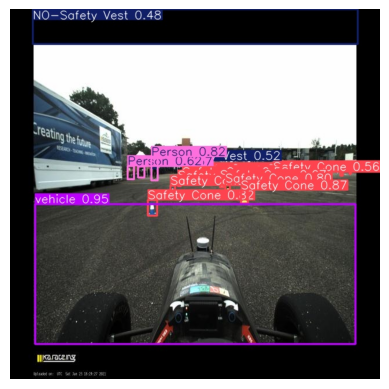


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg: 640x640 3 Hardhats, 3 NO-Masks, 3 NO-Safety Vests, 3 Persons, 44.7ms
Speed: 1.6ms preprocess, 44.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/images

Test Image 3: 004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg
Detected 12 objects:
  - Hardhat: 0.96
  - Hardhat: 0.96
  - NO-Safety Vest: 0.95
  - NO-Safety Vest: 0.94
  - Person: 0.94
  - Hardhat: 0.93
  - Person: 0.92
  - Person: 0.91
  - NO-Mask: 0.91
  - NO-Safety Vest: 0.90
  - NO-Mask: 0.90
  - NO-Mask: 0.80


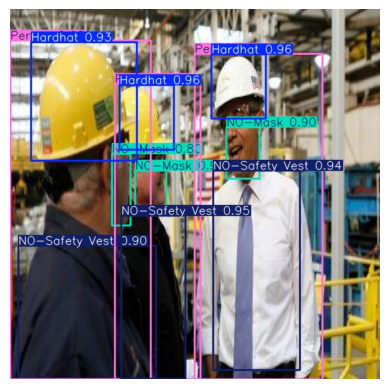


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-253_jpg.rf.5ad0a2d701e20141940508b809584856.jpg: 640x640 (no detections), 44.7ms
Speed: 1.6ms preprocess, 44.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/images

Test Image 4: youtube-253_jpg.rf.5ad0a2d701e20141940508b809584856.jpg
No objects detected


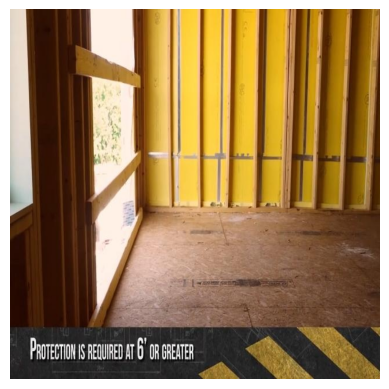


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/ppe_1073_jpg.rf.72ea8a293a4f3e1135219e33701b1099.jpg: 640x640 10 Hardhats, 8 NO-Masks, 11 Persons, 9 Safety Vests, 44.8ms
Speed: 1.5ms preprocess, 44.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/test_results/images

Test Image 5: ppe_1073_jpg.rf.72ea8a293a4f3e1135219e33701b1099.jpg
Detected 38 objects:
  - Hardhat: 0.95
  - Hardhat: 0.94
  - Safety Vest: 0.94
  - Safety Vest: 0.93
  - Safety Vest: 0.92
  - Person: 0.92
  - Safety Vest: 0.92
  - Person: 0.91
  - Safety Vest: 0.91
  - Person: 0.91
  - Safety Vest: 0.90
  - Person: 0.90
  - Person: 0.90
  - Person: 0.90
  - Hardhat: 0.90
  - Hardhat: 0.89
  - Person: 0.89
  - Safety Vest: 0.89
  - Safety Vest: 0.89
  - Person: 0.89
  - Person: 0.89
  - Safety Vest: 0.88
  - Hardhat: 0.88
  - Hardhat: 0.88
  - Hardhat: 0.88
  - NO-Mask: 0.87
  - NO-Mask: 0.85
  - Hardhat: 0.84
  - Person: 0.

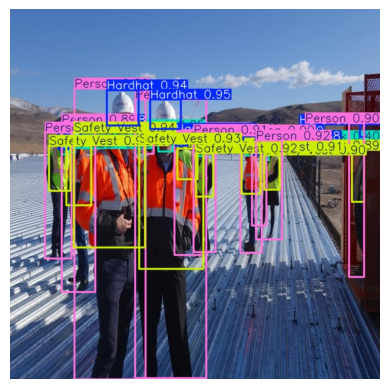

In [97]:
### Test on 5 random images
random.seed(CFG.SEED)
test_samples = random.sample(test_image_files, min(5, len(test_image_files)))

for idx, img_file in enumerate(test_samples, 1):
    test_img_path = os.path.join(test_images_path, img_file)
    
    # Run inference
    results = trained_model.predict(
        source=test_img_path,
        conf=0.25,  # Confidence threshold
        iou=0.45,   # NMS IoU threshold
        imgsz=640,
        device=[0],  # Use GPU
        save=True,
        save_txt=False,
        exist_ok=True,
        project=f'{CFG.OUTPUT_DIR}test_results',
        name='images'
    )
    
    print(f'\n{"="*60}')
    print(f'Test Image {idx}: {img_file}')
    print(f'{"="*60}')
    
    # Display detections
    for r in results:
        if len(r.boxes) > 0:
            print(f'Detected {len(r.boxes)} objects:')
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                print(f'  - {CFG.CLASSES[cls_id]}: {conf:.2f}')
        else:
            print('No objects detected')
    
    # Display result image
    result_img_path = f'{CFG.OUTPUT_DIR}test_results/images/{img_file}'
    if os.path.exists(result_img_path):
        display_image(result_img_path, print_info=False, hide_axis=True)

In [98]:
### Video inference
# Replace with your video path
video_path = '/kaggle/input/your-video-file.mp4'  # Change this to your video path

if os.path.exists(video_path):
    print(f'Processing video: {video_path}')
    
    # Run inference on video
    results = trained_model.predict(
        source=video_path,
        conf=0.30,
        iou=0.45,
        imgsz=640,
        device=[0],
        save=True,
        stream=True,  # Stream mode for videos
        project=f'{CFG.OUTPUT_DIR}test_results',
        name='video'
    )
    
    # Process results
    frame_count = 0
    for r in results:
        frame_count += 1
        if frame_count % 30 == 0:  # Print every 30 frames
            print(f'Processed {frame_count} frames...')
    
    print(f'\nVideo processing complete! Total frames: {frame_count}')
    print(f'Output saved to: {CFG.OUTPUT_DIR}test_results/video/')
else:
    print(f'Video not found at: {video_path}')
    print('Please upload a video file or update the video_path variable')

Video not found at: /kaggle/input/your-video-file.mp4
Please upload a video file or update the video_path variable


In [99]:
### Create a video from test images for demonstration
output_video_path = f'{CFG.OUTPUT_DIR}test_video.mp4'

# Select first 50 test images
video_test_images = test_image_files[:50]

if len(video_test_images) > 0:
    # Read first image to get dimensions
    first_img = cv2.imread(os.path.join(test_images_path, video_test_images[0]))
    height, width, _ = first_img.shape
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = 5  # 5 frames per second
    video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    
    print(f'Creating video from {len(video_test_images)} images...')
    
    for img_file in video_test_images:
        img_path = os.path.join(test_images_path, img_file)
        frame = cv2.imread(img_path)
        if frame is not None:
            video_writer.write(frame)
    
    video_writer.release()
    print(f'Video created: {output_video_path}')
    print(f'Video specs: {width}x{height}, {fps} FPS, {len(video_test_images)} frames')
else:
    print('No test images available to create video')

Creating video from 50 images...
Video created: /kaggle/working/test_video.mp4
Video specs: 640x640, 5 FPS, 50 frames


In [100]:
### Run inference on the created video
if os.path.exists(output_video_path):
    print(f'Running inference on created video...')
    
    results = trained_model.predict(
        source=output_video_path,
        conf=0.25,
        iou=0.45,
        imgsz=640,
        device=[0],
        save=True,
        stream=True,
        project=f'{CFG.OUTPUT_DIR}test_results',
        name='demo_video'
    )
    
    # Process results
    frame_count = 0
    detection_summary = {cls: 0 for cls in CFG.CLASSES}
    
    for r in results:
        frame_count += 1
        for box in r.boxes:
            cls_id = int(box.cls[0])
            detection_summary[CFG.CLASSES[cls_id]] += 1
    
    print(f'\n{"="*60}')
    print(f'Video Inference Complete!')
    print(f'{"="*60}')
    print(f'Total frames processed: {frame_count}')
    print(f'\nDetection Summary (total detections across all frames):')
    for cls_name, count in detection_summary.items():
        if count > 0:
            print(f'  {cls_name}: {count}')
    
    print(f'\nOutput video saved to: {CFG.OUTPUT_DIR}test_results/demo_video/')
else:
    print('Video file not created')

Running inference on created video...

video 1/1 (frame 1/50) /kaggle/working/test_video.mp4: 640x640 1 Hardhat, 1 Person, 1 Safety Vest, 1 machinery, 48.8ms
video 1/1 (frame 2/50) /kaggle/working/test_video.mp4: 640x640 3 Hardhats, 2 NO-Masks, 3 NO-Safety Vests, 3 Persons, 48.7ms
video 1/1 (frame 3/50) /kaggle/working/test_video.mp4: 640x640 1 Person, 48.6ms
video 1/1 (frame 4/50) /kaggle/working/test_video.mp4: 640x640 3 Hardhats, 3 NO-Masks, 3 NO-Safety Vests, 3 Persons, 46.9ms
video 1/1 (frame 5/50) /kaggle/working/test_video.mp4: 640x640 1 Mask, 1 NO-Hardhat, 1 NO-Safety Vest, 1 Person, 45.3ms
video 1/1 (frame 6/50) /kaggle/working/test_video.mp4: 640x640 5 Persons, 8 machinerys, 9 vehicles, 44.8ms
video 1/1 (frame 7/50) /kaggle/working/test_video.mp4: 640x640 1 Hardhat, 1 NO-Safety Vest, 1 Person, 44.3ms
video 1/1 (frame 8/50) /kaggle/working/test_video.mp4: 640x640 5 Hardhats, 1 NO-Hardhat, 5 NO-Safety Vests, 6 Persons, 1 Safety Vest, 44.8ms
video 1/1 (frame 9/50) /kaggle/workin

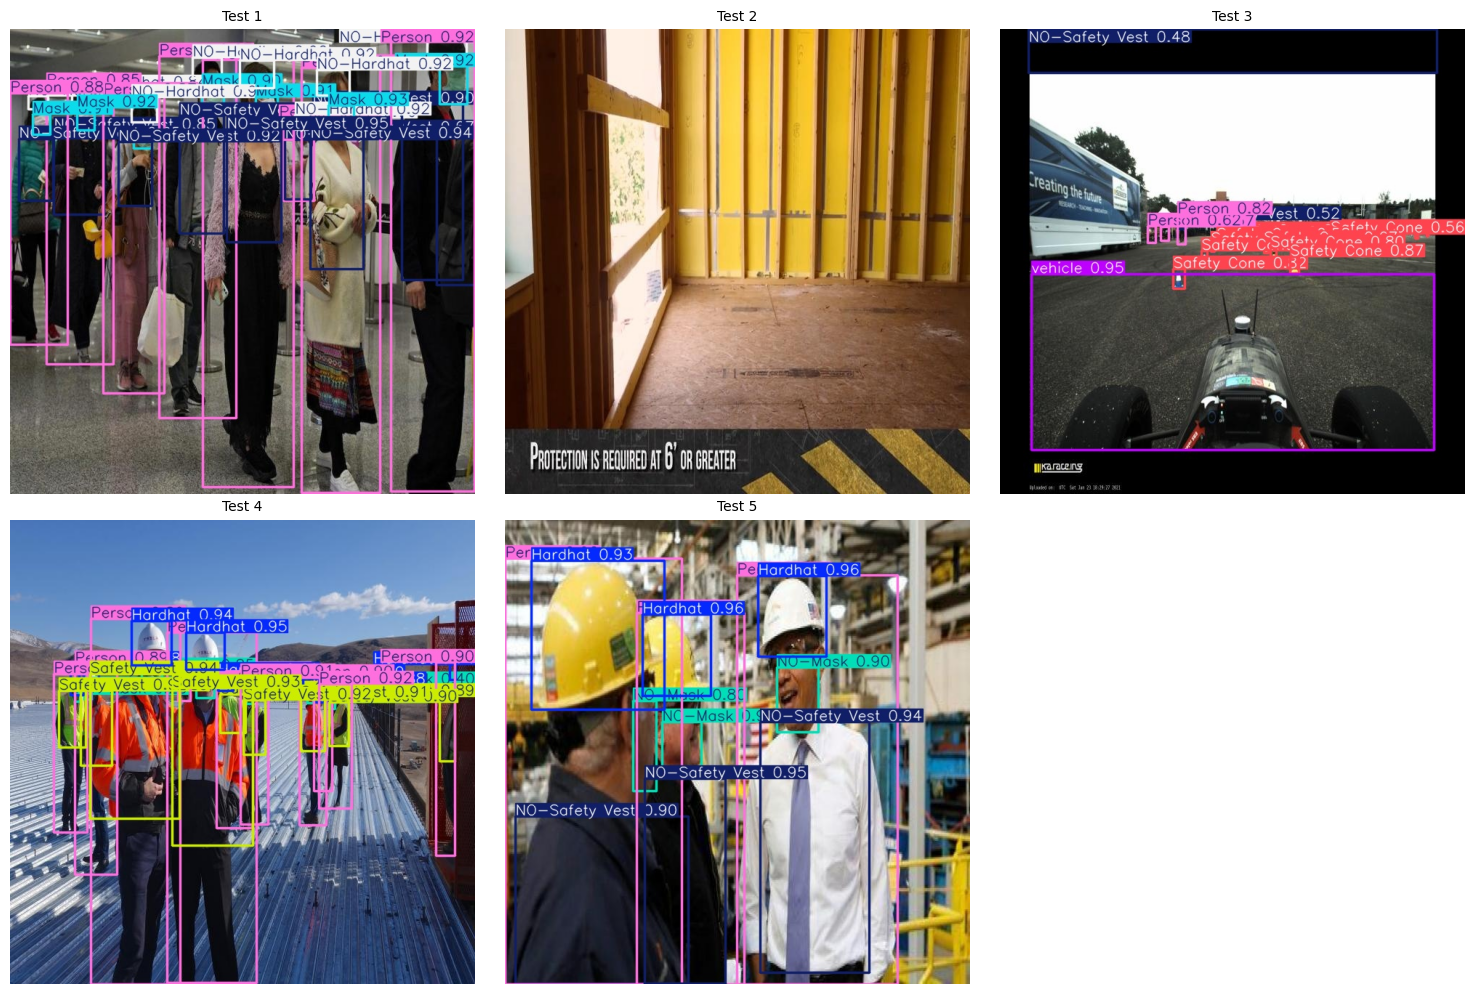

In [101]:
### Display 12 test results in a grid
test_results_dir = f'{CFG.OUTPUT_DIR}test_results/images/'

if os.path.exists(test_results_dir):
    result_files = [f for f in os.listdir(test_results_dir) if f.endswith(('.jpg', '.png'))]
    
    num_images = min(12, len(result_files))
    display_files = result_files[:num_images]
    
    # Create subplot grid
    num_cols = 3
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
    
    if num_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, file_name in enumerate(display_files):
        row = i // num_cols
        col = i % num_cols
        
        img = Image.open(os.path.join(test_results_dir, file_name))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'Test {i+1}', fontsize=10)
    
    # Remove empty subplots
    for i in range(num_images, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()
else:
    print('No test results found. Run the test cells above first.')

In [102]:
### Model file location
print(f'Best model location: {best_model_path}')
print(f'\nModel file size: {os.path.getsize(best_model_path) / (1024*1024):.2f} MB')
print(f'\nClasses trained: {CFG.CLASSES}')
print(f'Number of classes: {CFG.NUM_CLASSES_TO_TRAIN}')
print(f'Total epochs: {CFG.EPOCHS}')
print(f'\n{"="*60}')
print('Download this file from the Kaggle output and share with your team!')
print('{"="*60}')

Best model location: /kaggle/working/runs/detect/yolov9e_ppe_css_70_epochs/weights/best.pt

Model file size: 111.84 MB

Classes trained: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
Number of classes: 10
Total epochs: 70

Download this file from the Kaggle output and share with your team!
{"="*60}


In [103]:
### Copy model to easy-to-find location for download
import shutil
from datetime import datetime

# Create a simple filename with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
final_model_name = f'ppe_detection_model_{timestamp}.pt'
final_model_path = os.path.join(CFG.OUTPUT_DIR, final_model_name)

# Copy the best model
shutil.copy2(best_model_path, final_model_path)

print(f'✅ Model saved for your friend!')
print(f'\n📁 File Location: {final_model_path}')
print(f'📦 File Name: {final_model_name}')
print(f'💾 File Size: {os.path.getsize(final_model_path) / (1024*1024):.2f} MB')
print(f'\n{"="*60}')
print(f'DOWNLOAD THIS FILE from Kaggle Output:')
print(f'  → {final_model_name}')
print(f'{"="*60}')
print(f'\n📝 Share this file with your team for real-time detection!')

✅ Model saved for your friend!

📁 File Location: /kaggle/working/ppe_detection_model_20260116_0257.pt
📦 File Name: ppe_detection_model_20260116_0257.pt
💾 File Size: 111.84 MB

DOWNLOAD THIS FILE from Kaggle Output:
  → ppe_detection_model_20260116_0257.pt

📝 Share this file with your team for real-time detection!


In [104]:
# Test on video - Real-time visualization
video_path = '/kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4'

if os.path.exists(video_path):
    print(f'🎥 Starting real-time video detection: {video_path}\n')
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f'Video: {total_frames} frames, {fps:.1f} FPS, {width}x{height}')
    print(f'Processing and displaying detections in real-time...\n')
    
    # Setup matplotlib for real-time display
    from IPython.display import clear_output
    import matplotlib.pyplot as plt
    
    frame_count = 0
    display_every = 5  # Display every 5th frame to avoid slowdown
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # Run detection
        results = model.predict(
            source=frame,
            conf=CFG.CONF_THRESHOLD,
            iou=CFG.IOU_THRESHOLD,
            imgsz=CFG.IMG_SIZE,
            device=[0] if os.path.exists('/dev/nvidia0') else 'cpu',
            verbose=False
        )
        
        # Get annotated frame
        annotated_frame = results[0].plot()
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        
        # Display every Nth frame
        if frame_count % display_every == 0 or frame_count == 1:
            clear_output(wait=True)
            
            plt.figure(figsize=(15, 10))
            plt.imshow(annotated_frame_rgb)
            plt.axis('off')
            plt.title(f'Frame {frame_count}/{total_frames} - {len(results[0].boxes)} detections', 
                     fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        
        # Break after 200 frames to avoid timeout (optional)
        if frame_count >= 200:
            print(f'\n⚠️ Stopped at frame {frame_count} (limit reached)')
            break
    
    cap.release()
    print(f'\n✅ Processed {frame_count} frames')
    
else:
    print(f'❌ Video not found: {video_path}')

🎥 Starting real-time video detection: /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4

Video: 648 frames, 30.0 FPS, 1280x720
Processing and displaying detections in real-time...



AttributeError: type object 'CFG' has no attribute 'CONF_THRESHOLD'